In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("10_powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [4]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)


In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [6]:
import torch
import torch.nn as nn

In [7]:
x_train_tensor=torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [8]:
from torch.utils.data import TensorDataset,DataLoader

Train_data=TensorDataset(x_train_tensor,y_train_tensor)
Test_data=TensorDataset(x_test_tensor,y_test_tensor)

In [9]:
Train_loader=DataLoader(Train_data,batch_size=32,shuffle=True)
Test_loader=DataLoader(Test_data,batch_size=32)

DeepLearning

In [26]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(

            #1 layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            #2 Layer

            nn.Linear(6,6),
            nn.ReLU(),

            #Ouput layer
            nn.Linear(6,1)
        )
    def forward(self,x):
        return self.model(x)
            
        
    


In [27]:
import torch.optim as optim

model=ANN()
#losss & Optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

Trianing The Model

In [29]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in Train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(Train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in Test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(Test_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "10_best_model.pt") #.pt or .pth
          
   
    
        
        
        
        

epoch 1/100 ==> train loss = 206403.2400390625 & val loss = 205126.734375
epoch 2/100 ==> train loss = 200660.2583984375 & val loss = 192998.21875
epoch 3/100 ==> train loss = 178893.659765625 & val loss = 161291.90625
epoch 4/100 ==> train loss = 138176.15657552084 & val loss = 113681.9921875
epoch 5/100 ==> train loss = 88947.25639648437 & val loss = 66498.2421875
epoch 6/100 ==> train loss = 49034.384537760416 & val loss = 35692.6953125
epoch 7/100 ==> train loss = 28224.481030273437 & val loss = 23063.1953125
epoch 8/100 ==> train loss = 20635.194291178384 & val loss = 18556.638671875
epoch 9/100 ==> train loss = 17359.79055582682 & val loss = 15753.23046875
epoch 10/100 ==> train loss = 14767.948223876952 & val loss = 13171.3447265625
epoch 11/100 ==> train loss = 12172.922332763672 & val loss = 10642.28125
epoch 12/100 ==> train loss = 9691.18592936198 & val loss = 8244.7216796875
epoch 13/100 ==> train loss = 7336.724060058594 & val loss = 6046.6494140625
epoch 14/100 ==> train 

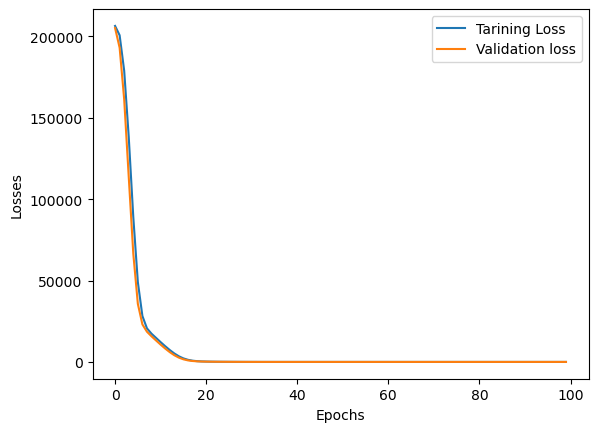

In [33]:
import matplotlib.pyplot as plt


loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"],label="Tarining Loss")
plt.plot(loss_df["Validation Loss"],label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [35]:
#Loading The best model
model.load_state_dict(torch.load("10_best_model.pt"))


<All keys matched successfully>

In [36]:
#Evaluation

model.eval()
with torch.no_grad():
    train_pred=model(x_train_tensor)
    test_pred=model(x_test_tensor)

    test_mse_loss=criterion(test_pred,y_test_tensor)

print("Testing mse:",test_mse_loss.item())

Testing mse: 17.747692108154297


In [37]:
from sklearn.metrics import r2_score

print("R2_score is:",r2_score(y_test,test_pred))

R2_score is: 0.9379763948851035
